<a href="https://colab.research.google.com/github/Osmancan-Kucdemir/denemeJava/blob/main/projeson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Veri seti başarıyla yüklendi.


/tmp/ipykernel_1750/1050898180.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette='Set2')


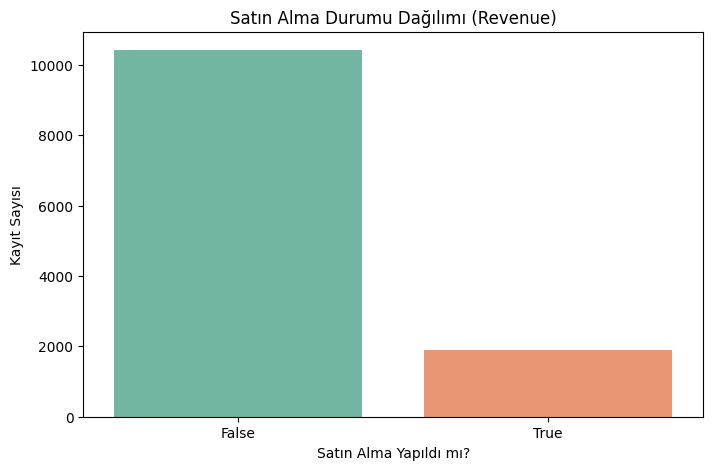

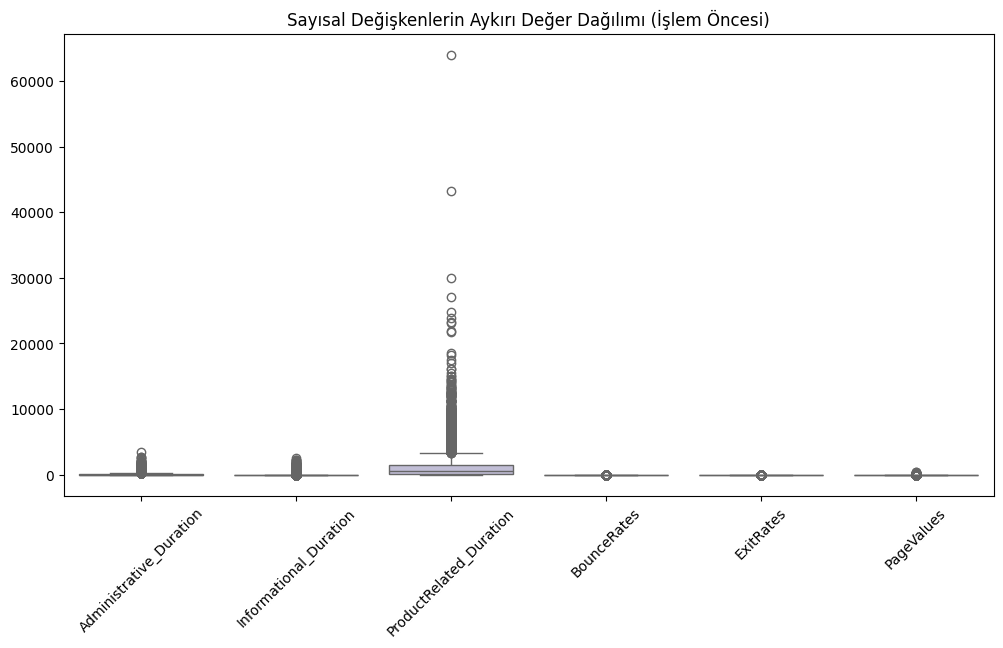

Modeller 0.3 eşik değeri ile değerlendiriliyor...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



TABLO: 0.30 THRESHOLD İLE SONUÇLAR
         Algoritma  Doğruluk  Hassasiyet  Duyarlılık  F1-Skoru      AUC
               CNN  0.716951    0.298982    0.615183  0.402397 0.742677
    Rastgele Orman  0.680860    0.269099    0.617801  0.374901 0.741670
               SVM  0.742498    0.289517    0.455497  0.354018 0.700797
Lojistik Regresyon  0.635036    0.242032    0.636126  0.350649 0.699629
  K-En Yakın Komşu  0.646796    0.231614    0.552356  0.326373 0.666911
       Karar Ağacı  0.747364    0.270476    0.371728  0.313120 0.593973


/tmp/ipykernel_1750/1050898180.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Algoritma', y='F1-Skoru', data=results_df, palette='viridis')


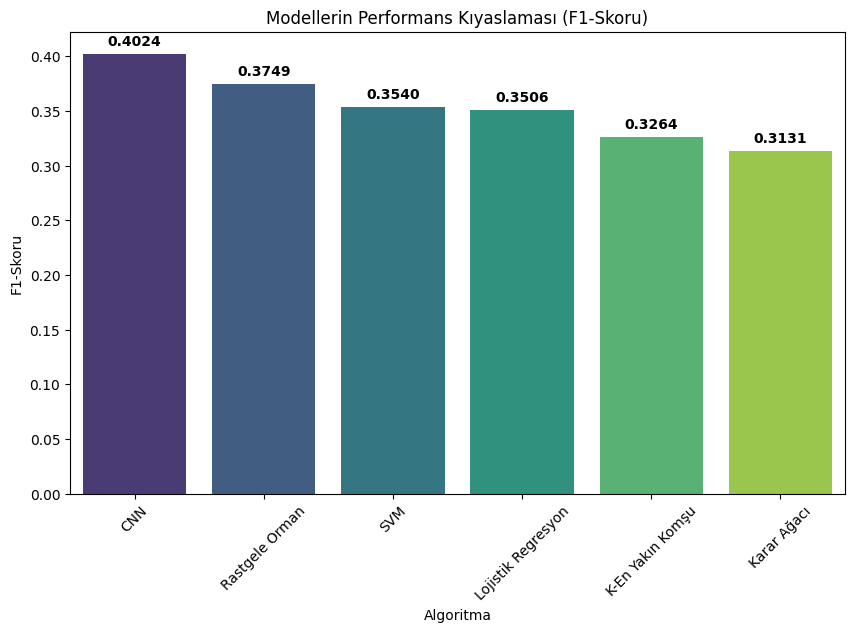

/tmp/ipykernel_1750/1050898180.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem', y='Özellik', data=feature_importance_df.head(10), palette='magma')


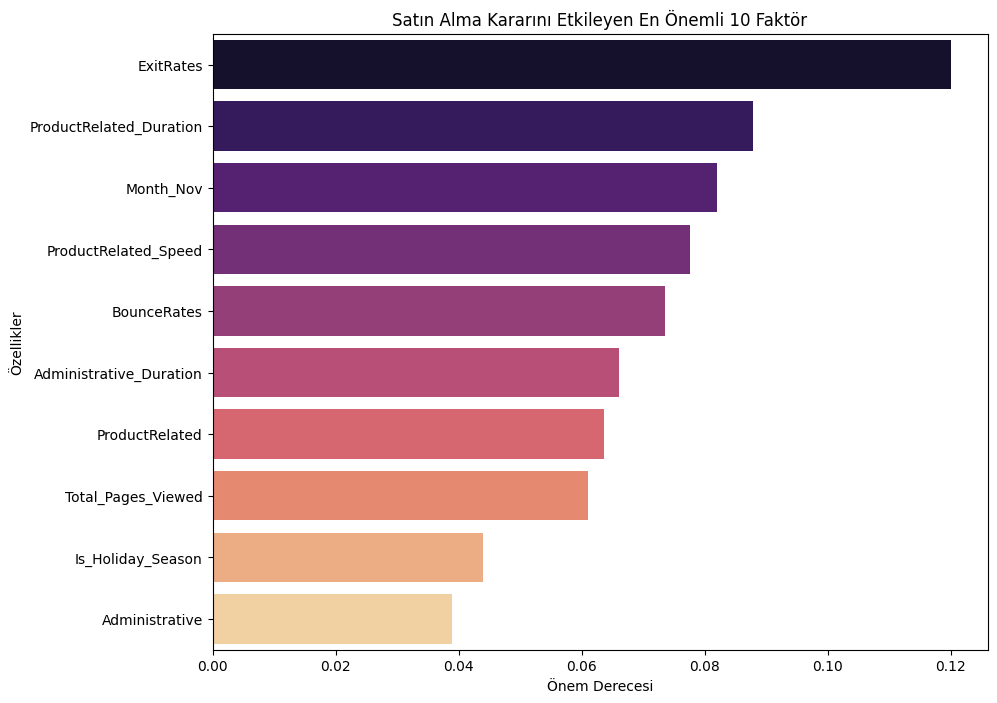

In [2]:
# 1. KÜTÜPHANELER
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

# Algoritmalar
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
import tensorflow as tf
from tensorflow.keras import layers, models

# --- TUTARLILIK İÇİN SONUÇLARI SABİTLEME ---
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# 2. VERİ YÜKLEME
try:
    df = pd.read_csv("online_shoppers_intention.csv")
    print("Veri seti başarıyla yüklendi.")
except FileNotFoundError:
    print("HATA: Dosya bulunamadı!")

# --- GRAFİK 1: HEDEF DEĞİŞKEN DAĞILIMI (SINIF DENGESİZLİĞİ) ---
plt.figure(figsize=(8, 5))
sns.countplot(x='Revenue', data=df, palette='Set2')
plt.title('Satın Alma Durumu Dağılımı (Revenue)')
plt.xlabel('Satın Alma Yapıldı mı?')
plt.ylabel('Kayıt Sayısı')
plt.show()

# 3. AYKIRI DEĞER ANALİZİ (IQR)
num_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']

# --- GRAFİK 2: AYKIRI DEĞER ANALİZİ (İŞLEM ÖNCESİ) ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], palette='Set3')
plt.title('Sayısal Değişkenlerin Aykırı Değer Dağılımı (İşlem Öncesi)')
plt.xticks(rotation=45)
plt.show()

# Aykırı değerleri baskılama
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.where(df[col] > (Q3 + 1.5 * IQR), Q3 + 1.5 * IQR, np.where(df[col] < (Q1 - 1.5 * IQR), Q1 - 1.5 * IQR, df[col]))

# --- 3.1. ÖZELLİK MÜHENDİSLİĞİ ---
df['ProductRelated_Speed'] = df['ProductRelated_Duration'] / (df['ProductRelated'] + 0.001)
df['Value_Per_Exit'] = df['PageValues'] / (df['ExitRates'] + 0.001)
df['Total_Pages_Viewed'] = df['Administrative'] + df['Informational'] + df['ProductRelated']
df['Is_Holiday_Season'] = df['Month'].apply(lambda x: 1 if x in ['Nov', 'Dec'] else 0)

# 4. VERİ ÖN İŞLEME
df_encoded = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)
le = LabelEncoder()
df_encoded['Revenue'] = le.fit_transform(df_encoded['Revenue'])
df_encoded['Weekend'] = le.fit_transform(df_encoded['Weekend'])

X_final = df_encoded.drop('Revenue', axis=1)
y_final = df_encoded['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.20, random_state=42, stratify=y_final)

# SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# 5. MODELLERİN EĞİTİLMESİ (THRESHOLD GÜNCELLEMESİ)
results = []
clf_list = {
    "Rastgele Orman": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Karar Ağacı": DecisionTreeClassifier(random_state=42),
    "K-En Yakın Komşu": KNeighborsClassifier(),
    "SVM": SVC(random_state=42, probability=True, class_weight='balanced'),
    "Lojistik Regresyon": LogisticRegression(random_state=42, class_weight='balanced'),
}

THRESHOLD = 0.30
print(f"Modeller {THRESHOLD} eşik değeri ile değerlendiriliyor...")

for name, model in clf_list.items():
    model.fit(X_train_sc, y_train)
    y_probs = model.predict_proba(X_test_sc)[:, 1]
    y_pred_custom = (y_probs >= THRESHOLD).astype(int)

    results.append({
        "Algoritma": name,
        "Doğruluk": accuracy_score(y_test, y_pred_custom),
        "Hassasiyet": precision_score(y_test, y_pred_custom),
        "Duyarlılık": recall_score(y_test, y_pred_custom),
        "F1-Skoru": f1_score(y_test, y_pred_custom),
        "AUC": roc_auc_score(y_test, y_probs)
    })

# --- CNN Uygulaması ---
X_train_cnn = np.expand_dims(X_train_sc, axis=2)
X_test_cnn = np.expand_dims(X_test_sc, axis=2)
cnn = models.Sequential([
    layers.Conv1D(32, 2, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn.fit(X_train_cnn, y_train, epochs=10, verbose=0)

y_probs_cnn = cnn.predict(X_test_cnn, verbose=0).flatten()
y_pred_cnn_custom = (y_probs_cnn >= THRESHOLD).astype(int)

results.append({
    "Algoritma": "CNN",
    "Doğruluk": accuracy_score(y_test, y_pred_cnn_custom),
    "Hassasiyet": precision_score(y_test, y_pred_cnn_custom),
    "Duyarlılık": recall_score(y_test, y_pred_cnn_custom),
    "F1-Skoru": f1_score(y_test, y_pred_cnn_custom),
    "AUC": roc_auc_score(y_test, y_probs_cnn)
})

# 6. SONUÇLAR VE TABLO
results_df = pd.DataFrame(results).sort_values(by="F1-Skoru", ascending=False)
print("\nTABLO: 0.30 THRESHOLD İLE SONUÇLAR\n", "="*85)
print(results_df.to_string(index=False))

# --- GRAFİK 3: MODELLERİN F1-SKORU KIYASLAMASI ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Algoritma', y='F1-Skoru', data=results_df, palette='viridis')
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')
plt.title('Modellerin Performans Kıyaslaması (F1-Skoru)')
plt.xticks(rotation=45)
plt.show()

# --- GRAFİK 4: EN ÖNEMLİ 10 FAKTÖR (FEATURE IMPORTANCE) ---
# Rastgele Orman üzerinden öznitelik önemini alıyoruz
rf_model = clf_list["Rastgele Orman"]
importances = rf_model.feature_importances_
feature_names = X_final.columns
feature_importance_df = pd.DataFrame({'Özellik': feature_names, 'Önem': importances}).sort_values(by='Önem', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Önem', y='Özellik', data=feature_importance_df.head(10), palette='magma')
plt.title('Satın Alma Kararını Etkileyen En Önemli 10 Faktör')
plt.xlabel('Önem Derecesi')
plt.ylabel('Özellikler')
plt.show()

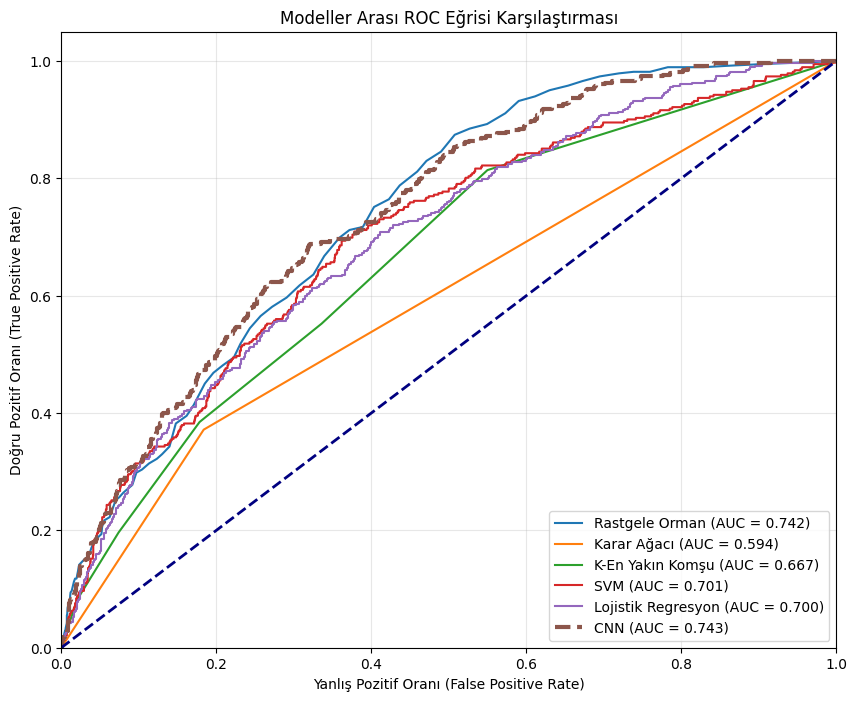

In [3]:
# --- ROC EĞRİSİ VE AUC ANALİZİ ---
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# 1. Klasik Modeller İçin ROC Çizimi
for name, model in clf_list.items():
    # Olasılıkları alıyoruz
    y_probs = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

# 2. CNN İçin ROC Çizimi (Ayrı hesaplanması gerekiyor)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_probs_cnn)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN (AUC = {roc_auc_cnn:.3f})', linewidth=3, linestyle='--')

# 3. Şans Çizgisi (Referans)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Grafik Ayarları
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (False Positive Rate)')
plt.ylabel('Doğru Pozitif Oranı (True Positive Rate)')
plt.title('Modeller Arası ROC Eğrisi Karşılaştırması')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

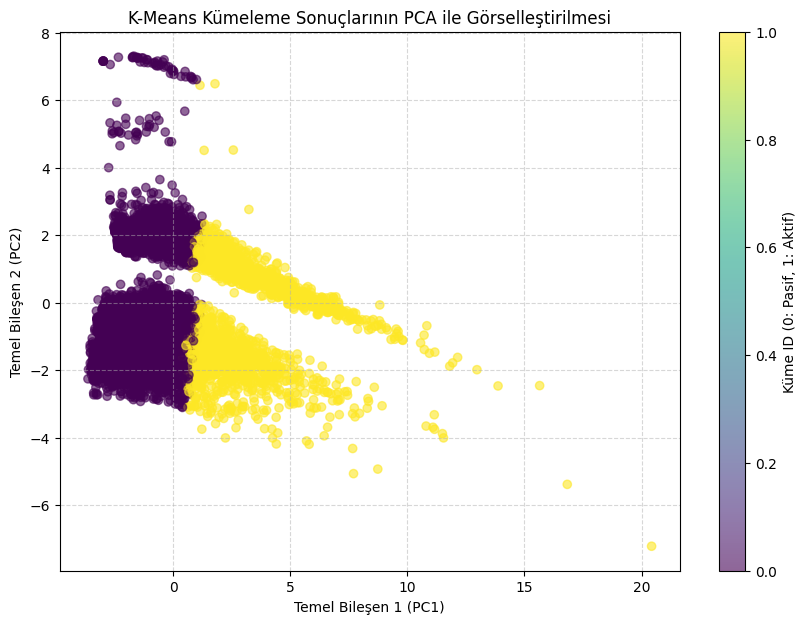


KÜME ÖZETLERİ (Ortalama Değerler):
         ProductRelated_Duration  PageValues  ExitRates   Revenue
Cluster                                                          
0                     572.049113         0.0   0.042540  0.118777
1                    2196.506547         0.0   0.018859  0.258675


In [4]:
# --- KÜMELEME ANALİZİ VE PCA GÖRSELLEŞTİRMESİ ---
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Kümeleme için tüm ölçeklendirilmiş veriyi kullanıyoruz
# Not: Modeller için kullanılan X_train_sc yerine tüm veri setini (X_final) görmek daha anlamlıdır
X_scaled_full = scaler.fit_transform(X_final)

# 1. K-Means Uygulama (Raporunla uyumlu olması için küme sayısı = 2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled_full)

# 2. PCA (Temel Bileşen Analizi) ile 2 Boyuta İndirgeme
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_full)

# 3. Görselleştirme
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)

# Grafik detayları
plt.colorbar(scatter, label='Küme ID (0: Pasif, 1: Aktif)')
plt.title('K-Means Kümeleme Sonuçlarının PCA ile Görselleştirilmesi')
plt.xlabel('Temel Bileşen 1 (PC1)')
plt.ylabel('Temel Bileşen 2 (PC2)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Küme merkezlerini ve özellik dağılımlarını görmek istersen:
df['Cluster'] = clusters
print("\nKÜME ÖZETLERİ (Ortalama Değerler):")
print(df.groupby('Cluster')[['ProductRelated_Duration', 'PageValues', 'ExitRates', 'Revenue']].mean())

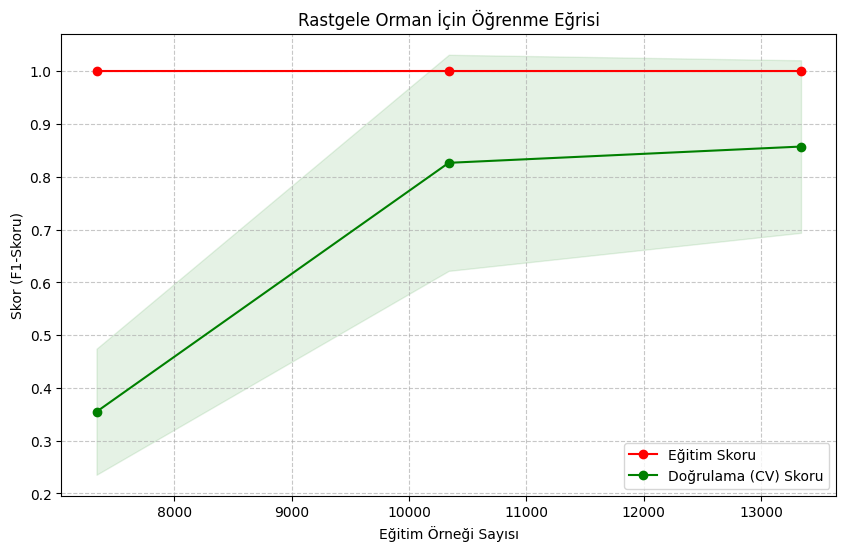

In [5]:
# --- ÖĞRENME EĞRİSİ (LEARNING CURVE) ANALİZİ ---
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Eğitim Örneği Sayısı")
    plt.ylabel("Skor (F1-Skoru)")

    # Learning curve hesaplama (F1-skoru odaklı)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='f1'
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid(True, linestyle='--', alpha=0.7)

    # Alanları renklendirme (Hata payı)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")

    # Çizgileri çizme
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Eğitim Skoru")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Doğrulama (CV) Skoru")

    plt.legend(loc="best")
    plt.show()

# Rastgele Orman modelin için grafiği çizdiriyoruz
# Not: Modeli eğitmeden ham haliyle veriyoruz, fonksiyon içinde CV ile eğitecek
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

plot_learning_curve(rf_model, "Rastgele Orman İçin Öğrenme Eğrisi", X_train_sc, y_train)

/tmp/ipykernel_1750/679161863.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Revenue', data=df, palette='viridis')


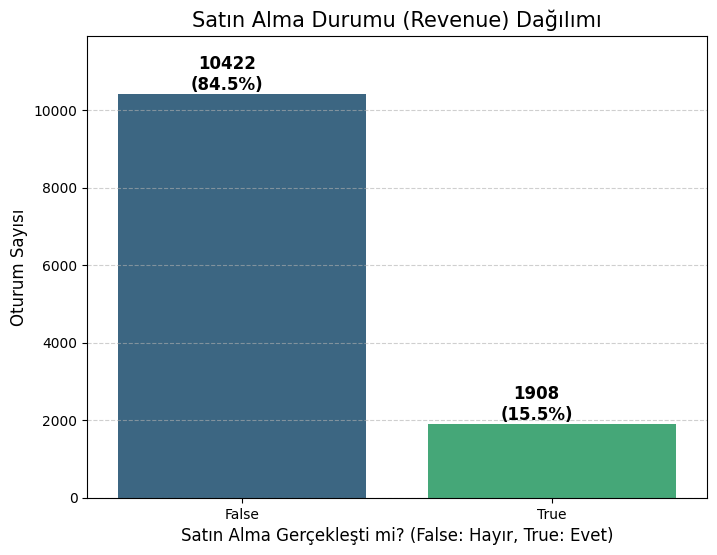

Sınıf Dağılımı:
Revenue
False    10422
True      1908
Name: count, dtype: int64


In [6]:
# --- HEDEF DEĞİŞKEN (REVENUE) DAĞILIMI ---
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Revenue', data=df, palette='viridis')

# Çubukların üzerine sayı ve yüzde ekleme
total = len(df['Revenue'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 100
    ax.annotate(f'{int(p.get_height())}\n({percentage})', (x, y), ha='center', fontsize=12, fontweight='bold')

plt.title('Satın Alma Durumu (Revenue) Dağılımı', fontsize=15)
plt.xlabel('Satın Alma Gerçekleşti mi? (False: Hayır, True: Evet)', fontsize=12)
plt.ylabel('Oturum Sayısı', fontsize=12)
plt.ylim(0, max(df['Revenue'].value_counts()) + 1500) # Üstten biraz boşluk bırakalım
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Sayısal dökümü görmek istersen:
print("Sınıf Dağılımı:")
print(df['Revenue'].value_counts())

<Figure size 800x600 with 0 Axes>

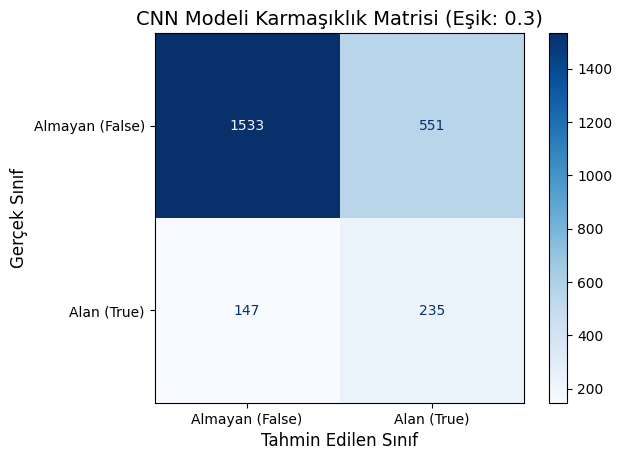

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. 0.30 eşiğine göre tahminleri oluşturuyoruz
threshold = 0.30
y_pred_cnn_optimized = (y_probs_cnn >= threshold).astype(int)

# 2. Matrisi hesaplıyoruz
cm = confusion_matrix(y_test, y_pred_cnn_optimized)

# 3. Görselleştirme
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Almayan (False)', 'Alan (True)'])
disp.plot(cmap='Blues', values_format='d')

plt.title(f'CNN Modeli Karmaşıklık Matrisi (Eşik: {threshold})', fontsize=14)
plt.xlabel('Tahmin Edilen Sınıf', fontsize=12)
plt.ylabel('Gerçek Sınıf', fontsize=12)
plt.show()

In [8]:
 from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_probs_cnn)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'CNN (PR AUC = {pr_auc:.3f})', color='purple', lw=2)
plt.xlabel('Duyarlılık (Recall)')
plt.ylabel('Kesinlik (Precision)')
plt.title('Precision-Recall Eğrisi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

SyntaxError: invalid syntax (2993818626.py, line 1)

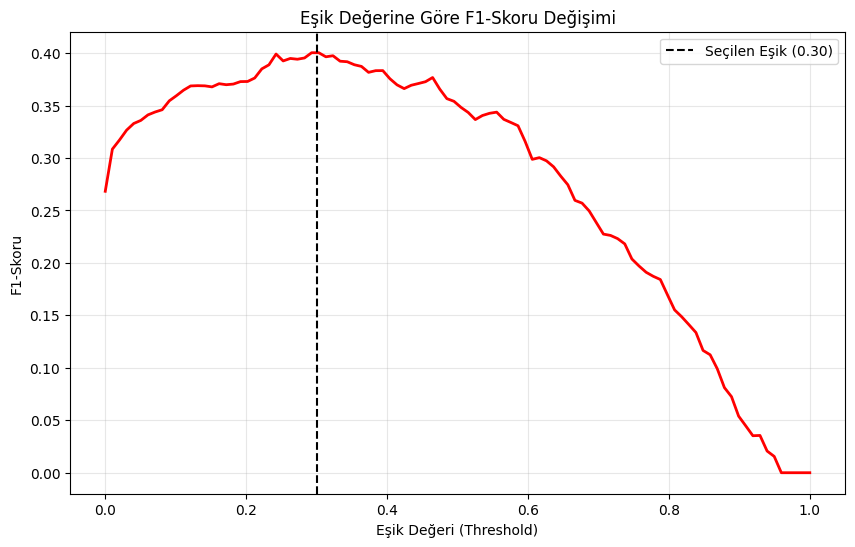

In [9]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.linspace(0, 1, 100)
f1_scores = [f1_score(y_test, (y_probs_cnn >= t).astype(int)) for t in thresholds]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, color='red', lw=2)
plt.axvline(x=0.30, color='black', linestyle='--', label='Seçilen Eşik (0.30)')
plt.xlabel('Eşik Değeri (Threshold)')
plt.ylabel('F1-Skoru')
plt.title('Eşik Değerine Göre F1-Skoru Değişimi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

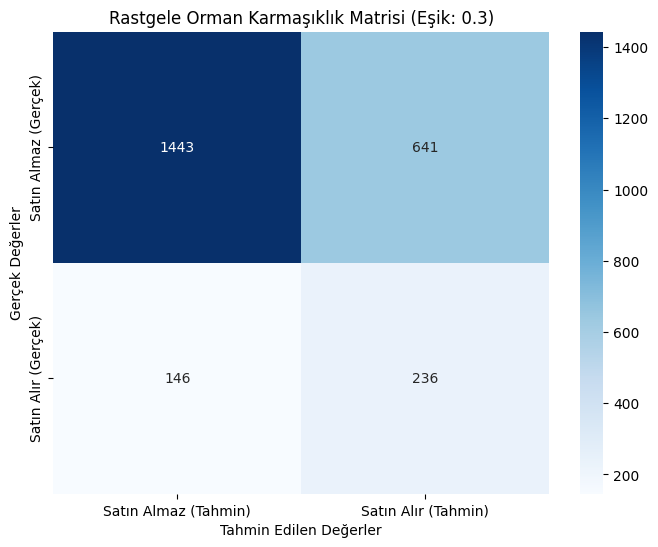


--- Hata Analizi Özeti ---
Doğru Negatif (Satın almayanları bildik): 1443
Yanlış Pozitif (Almayacaklara alacak dedik): 641 -> Gereksiz pazarlama maliyeti.
Yanlış Negatif (Alacakları kaçırdık): 146 -> Kayıp kazanç fırsatı.
Doğru Pozitif (Alacakları bildik): 236


In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. En iyi modelin (örneğin Rastgele Orman) olasılıklarını alalım
# Not: Eğer CNN için yapmak isterseniz 'rf_model' yerine 'cnn' ve 'X_test_sc' yerine 'X_test_cnn' kullanın.
rf_model = clf_list["Rastgele Orman"]
y_probs_rf = rf_model.predict_proba(X_test_sc)[:, 1]

# 2. Belirlediğiniz 0.30 eşik değerine göre tahminleri oluşturun
THRESHOLD = 0.30
y_pred_rf_custom = (y_probs_rf >= THRESHOLD).astype(int)

# 3. Matrisi hesapla
cm = confusion_matrix(y_test, y_pred_rf_custom)

# 4. Görselleştirme
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Satın Almaz (Tahmin)', 'Satın Alır (Tahmin)'],
            yticklabels=['Satın Almaz (Gerçek)', 'Satın Alır (Gerçek)'])

plt.title(f'Rastgele Orman Karmaşıklık Matrisi (Eşik: {THRESHOLD})')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# Hata Analizi Çıktısı
tn, fp, fn, tp = cm.ravel()
print(f"\n--- Hata Analizi Özeti ---")
print(f"Doğru Negatif (Satın almayanları bildik): {tn}")
print(f"Yanlış Pozitif (Almayacaklara alacak dedik): {fp} -> Gereksiz pazarlama maliyeti.")
print(f"Yanlış Negatif (Alacakları kaçırdık): {fn} -> Kayıp kazanç fırsatı.")
print(f"Doğru Pozitif (Alacakları bildik): {tp}")

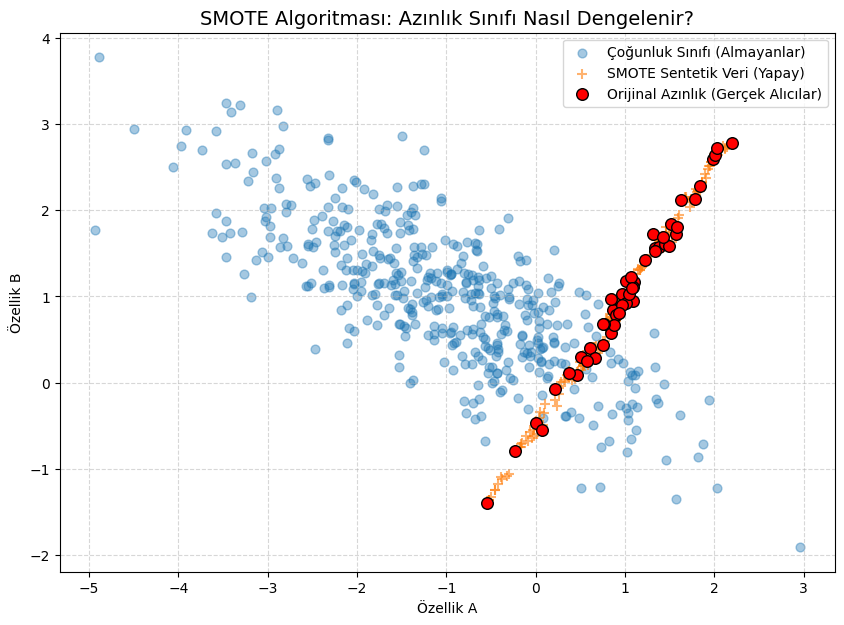

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE # Eğer hata alırsan: pip install imbalanced-learn

# 1. Sentetik dengesiz veri kümesi oluşturma (Gerçek verine benzer bir yapı)
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, weights=[0.90],
                           flip_y=0, random_state=42)

# 2. SMOTE uygulama
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# 3. Orijinal ve Sentetik noktaları ayırma
X_original_majority = X[y == 0]
X_original_minority = X[y == 1]
X_synthetic_minority = X_res[len(X):] # Yeni üretilenler

# 4. GÖRSELLEŞTİRME
plt.figure(figsize=(10, 7))

# Çoğunluk Sınıfı (Mavi) - Sitede bir şey almayan kalabalık kitle
plt.scatter(X_original_majority[:, 0], X_original_majority[:, 1],
            label='Çoğunluk Sınıfı (Almayanlar)', alpha=0.4, c='#1f77b4', s=40)

# SMOTE ile Üretilen Sentetik Noktalar (Turuncu) - Boşlukları dolduran yapay veriler
plt.scatter(X_synthetic_minority[:, 0], X_synthetic_minority[:, 1],
            label='SMOTE Sentetik Veri (Yapay)', c='#ff7f0e', alpha=0.6, marker='+', s=50)

# Orijinal Azınlık Sınıfı (Kırmızı) - Gerçek alıcılar
plt.scatter(X_original_minority[:, 0], X_original_minority[:, 1],
            label='Orijinal Azınlık (Gerçek Alıcılar)', c='red', s=70, edgecolors='k', zorder=5)

plt.title('SMOTE Algoritması: Azınlık Sınıfı Nasıl Dengelenir?', fontsize=14)
plt.xlabel('Özellik A')
plt.ylabel('Özellik B')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show() # Veya plt.savefig('smote_gorsel.png')